This is a fantastic request. The best way to see how these libraries fit together is to build a unified pipeline. 

To do this, we are going to build a **Salary Analysis Engine**. We will generate some synthetic employee data, test it mathematically, analyze the relationships for a formal report, train an AI to predict future salaries, and plot the whole thing.

Here is the "Grand Code" that brings the entire Python data science stack together.

### The Code

```python

### How the Ecosystem Worked Together Here:

1.  **NumPy** acts as the engine, generating and storing the raw arrays of numbers in memory.
2.  **Pandas** steps in to act like Excel, taking NumPy's raw arrays and giving them column names (`Experience`, `Salary`) so they are easy to read and filter.
3.  **SciPy** runs the pure mathematical algorithms (like the Shapiro-Wilk test) on those numbers to check their statistical properties.
4.  **Statsmodels** acts as the scientist, calculating exactly *how much* one variable impacts another and proving it with p-values and confidence intervals.
5.  **Scikit-Learn** acts as the engineer, ignoring the scientific proof and instead using a complex algorithm (Random Forest) purely to predict future numbers accurately.
6.  **Matplotlib** builds the literal window and axes for our graphs, while **Seaborn** paints the statistical trend lines over the data.

--- 1. Generating Data (NumPy & Pandas) ---
Dataset created with 500 records.

--- 2. Formal Statistical Testing (SciPy) ---
SciPy says: Salary is NOT normally distributed (p=0.000).

--- 3. Econometrics & Inference (Statsmodels) ---
Statsmodels Summary (Shortened for terminal):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.273e+04   2533.952     12.918      0.000    2.78e+04    3.77e+04
Experience  3602.6545     47.698     75.531      0.000    3508.940    3696.369
Education   4111.9241    176.836     23.253      0.000    3764.485    4459.363


--- 4. Predictive Machine Learning (Scikit-Learn) ---
Scikit-Learn Model Accuracy (R-squared): 89.7%

--- 5. Generating Visualizations (Matplotlib & Seaborn) ---


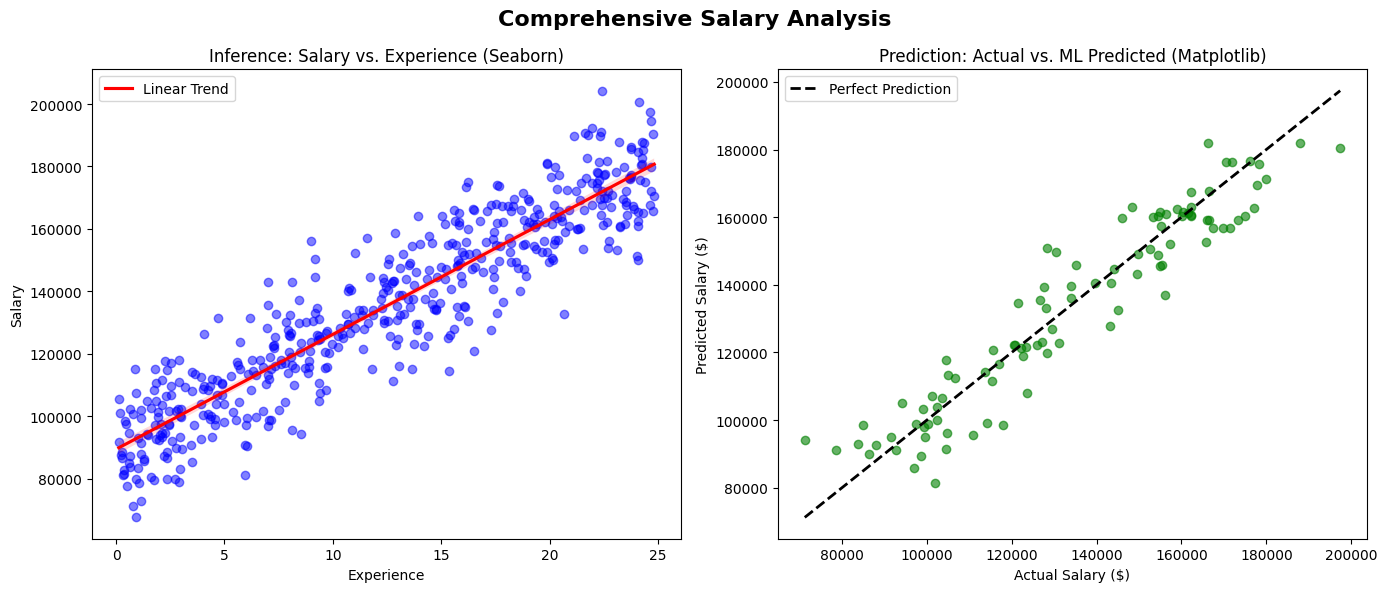

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# =====================================================================
# 1. NumPy & Pandas: The Foundation and Data Management
# =====================================================================
print("--- 1. Generating Data (NumPy & Pandas) ---")
np.random.seed(42) # For reproducibility
num_employees = 500

# NumPy: Generating raw numerical arrays
experience_years = np.random.uniform(0, 25, num_employees)
education_years = np.random.normal(14, 2, num_employees) 
noise = np.random.normal(0, 8000, num_employees)

# Creating a baseline formula for salary
salary = 35000 + (experience_years * 3500) + (education_years * 4000) + noise

# Pandas: Structuring the arrays into a clean, labeled DataFrame
df = pd.DataFrame({
    'Experience': experience_years,
    'Education': education_years,
    'Salary': salary
})

# Pandas: Quick cleanup (removing impossible negative experience)
df = df[df['Experience'] >= 0]
print(f"Dataset created with {len(df)} records.\n")


# =====================================================================
# 2. SciPy: Textbook Mathematics & Formal Statistics
# =====================================================================
print("--- 2. Formal Statistical Testing (SciPy) ---")
# Let's use SciPy to test if our salary data is normally distributed
# (Shapiro-Wilk test)
stat, p_value = stats.shapiro(df['Salary'])

if p_value > 0.05:
    print(f"SciPy says: Salary looks normally distributed (p={p_value:.3f}).\n")
else:
    print(f"SciPy says: Salary is NOT normally distributed (p={p_value:.3f}).\n")


# =====================================================================
# 3. Statsmodels: Inference (Why is this happening?)
# =====================================================================
print("--- 3. Econometrics & Inference (Statsmodels) ---")
# We want to mathematically prove how much an extra year of education is worth.
# We use an Ordinary Least Squares (OLS) regression using the Patsy formula syntax.
model = smf.ols('Salary ~ Experience + Education', data=df).fit()

# Statsmodels shines here by providing a massive, academic-grade report
print("Statsmodels Summary (Shortened for terminal):")
print(model.summary().tables[1]) 
print("\n")


# =====================================================================
# 4. Scikit-Learn: Machine Learning (What will happen next?)
# =====================================================================
print("--- 4. Predictive Machine Learning (Scikit-Learn) ---")
# We don't care about p-values anymore; we just want an AI to predict salaries.

# Split the data into Training (80%) and Testing (20%) sets
X = df[['Experience', 'Education']]
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest (a powerful, non-linear ML model)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on data the model has never seen
predictions = rf_model.predict(X_test)

# Evaluate how well the ML model did
accuracy = r2_score(y_test, predictions)
print(f"Scikit-Learn Model Accuracy (R-squared): {accuracy * 100:.1f}%\n")


# =====================================================================
# 5. Matplotlib & Seaborn: Visualization
# =====================================================================
print("--- 5. Generating Visualizations (Matplotlib & Seaborn) ---")
# Matplotlib: Setting up the blank canvas and grid layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comprehensive Salary Analysis', fontsize=16, fontweight='bold')

# Plot 1 (Seaborn): Statistical relationships 
# Seaborn is great at taking Pandas DataFrames and doing complex stats visually
sns.regplot(
    x='Experience', y='Salary', data=df, 
    ax=axes[0], 
    scatter_kws={'alpha': 0.5, 'color': 'blue'}, 
    line_kws={'color': 'red', 'label': 'Linear Trend'}
)
axes[0].set_title('Inference: Salary vs. Experience (Seaborn)')
axes[0].legend()

# Plot 2 (Matplotlib): Machine Learning evaluation
# Matplotlib is great for precise, custom plotting (like checking ML predictions)
axes[1].scatter(y_test, predictions, alpha=0.6, color='green')
axes[1].plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
    'k--', lw=2, label='Perfect Prediction'
)
axes[1].set_title('Prediction: Actual vs. ML Predicted (Matplotlib)')
axes[1].set_xlabel('Actual Salary ($)')
axes[1].set_ylabel('Predicted Salary ($)')
axes[1].legend()

# Display the final dashboard
plt.tight_layout()
plt.show()